# Package-backed method decision: pancreas and RegVelo Schwann

This notebook is the final software reproduction of the methodological decision. It uses package APIs rather than notebook-local solvers. Run it after installing the candidate package. The scientific acceptance criteria are:

- numerical conservation and solver convergence;
- future-fate affinity stability from effective horizon 64 to 128;
- affinity stability across endpoint anchor quantiles;
- deterministic/dynamical Schwann agreement;
- preservation, not correction, of unusual Delta, Epsilon, and Gut progression.

Automatic competing-outcome inference is intentionally absent. Competing outcomes may be added explicitly after biological review.


> **Execution provenance.** The displayed outputs were generated with scCS 0.8.0.dev33. Version 0.8.0.dev34 changes documentation and tutorial explanation only; the scientific calculations are unchanged.

In [1]:
from __future__ import annotations

import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import scvelo as scv
from scipy.spatial.distance import jensenshannon

import scCS

warnings.filterwarnings(
    "ignore",
    message="Please import `convolve` from the `scipy.ndimage` namespace",
    category=DeprecationWarning,
)

print("scCS", scCS.__version__)
print("scVelo", scv.__version__)

# Hide known warnings emitted by optional upstream dependencies. These do not
# change the scCS calculation and would otherwise distract from the tutorial.
warnings.filterwarnings(
    "ignore",
    message=r"This process .* is multi-threaded, use of fork\(\) may lead to deadlocks.*",
    category=DeprecationWarning,
)
warnings.filterwarnings(
    "ignore",
    category=DeprecationWarning,
    module=r"cellrank\..*",
)


scCS 0.8.0.dev33
scVelo 0.3.4


## Helpers


In [2]:
def row_js(left, right):
    return np.array([jensenshannon(a, b, base=2.0) ** 2 for a, b in zip(left, right)])


def align_result_cells(left, right, *, root_only=False):
    """Return aligned indices for two score results using stable cell IDs."""
    common_ids = pd.Index(left.cell_ids).intersection(right.cell_ids)
    left_index = pd.Index(left.cell_ids).get_indexer(common_ids)
    right_index = pd.Index(right.cell_ids).get_indexer(common_ids)
    keep = np.ones(len(common_ids), dtype=bool)
    if root_only:
        keep &= left.root_mask[left_index] & right.root_mask[right_index]
    return common_ids, left_index[keep], right_index[keep]


def score_source(adata, *, root, branches, obs_key, ordering_key, horizon=64, quantile=0.90):
    scorer = scCS.SingleScorer(
        adata,
        root=root,
        branches=branches,
        obs_key=obs_key,
    )
    scorer.build_embedding(
        ordering_metric=ordering_key,
        write_to_adata=False,
        verbose=False,
    )
    scorer.fit(
        scoring_mode="future_fate",
        future_fate_options={
            "effective_horizon": horizon,
            "anchor_quantile": quantile,
            "min_anchor_cells": 10,
            "progression_scale": "rank",
            "verbose": False,
        },
        verbose=False,
    )
    return scorer, scorer.score(write_to_adata=False, verbose=False)

## Pancreas dynamical velocity


In [3]:
pancreas = scv.datasets.pancreas()
scv.pp.filter_and_normalize(pancreas, min_shared_counts=20)
if "X_pca" not in pancreas.obsm:
    sc.pp.pca(pancreas, n_comps=30)
sc.pp.neighbors(pancreas, n_neighbors=30, n_pcs=30, use_rep="X_pca", random_state=0)
scv.pp.moments(pancreas, n_neighbors=None, n_pcs=None)
scv.tl.recover_dynamics(pancreas, n_jobs=1)
scv.tl.velocity(pancreas, mode="dynamical")
scv.tl.velocity_graph(pancreas)
scv.tl.latent_time(pancreas)

pancreas_scorer, pancreas_64 = score_source(
    pancreas,
    root=("Ngn3 high EP", "Pre-endocrine"),
    branches=["Alpha", "Beta", "Delta", "Epsilon"],
    obs_key="clusters",
    ordering_key="latent_time",
    horizon=64,
)
_, pancreas_128 = score_source(
    pancreas,
    root=("Ngn3 high EP", "Pre-endocrine"),
    branches=["Alpha", "Beta", "Delta", "Epsilon"],
    obs_key="clusters",
    ordering_key="latent_time",
    horizon=128,
)
_, pancreas_85 = score_source(
    pancreas,
    root=("Ngn3 high EP", "Pre-endocrine"),
    branches=["Alpha", "Beta", "Delta", "Epsilon"],
    obs_key="clusters",
    ordering_key="latent_time",
    horizon=64,
    quantile=0.85,
)
_, pancreas_95 = score_source(
    pancreas,
    root=("Ngn3 high EP", "Pre-endocrine"),
    branches=["Alpha", "Beta", "Delta", "Epsilon"],
    obs_key="clusters",
    ordering_key="latent_time",
    horizon=64,
    quantile=0.95,
)


Filtered out 20801 genes that are detected 20 counts (shared).
Normalized count data: X, spliced, unspliced.
computing moments based on connectivities
    finished (0:00:02) --> added 
    'Ms' and 'Mu', moments of un/spliced abundances (adata.layers)
recovering dynamics (using 1/24 cores)


  0%|          | 0/2722 [00:00<?, ?gene/s]

/home/emil/miniforge3/envs/lab-py312/lib/python3.12/multiprocessing/popen_fork.py:66: DeprecationWarning: This process (pid=92938) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid = os.fork()


    finished (0:24:58) --> added 
    'fit_pars', fitted parameters for splicing dynamics (adata.var)
computing velocities
    finished (0:00:10) --> added 
    'velocity', velocity vectors for each individual cell (adata.layers)
computing velocity graph (using 1/24 cores)


  0%|          | 0/3696 [00:00<?, ?cells/s]

/home/emil/miniforge3/envs/lab-py312/lib/python3.12/multiprocessing/popen_fork.py:66: DeprecationWarning: This process (pid=92938) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid = os.fork()


    finished (0:00:18) --> added 
    'velocity_graph', sparse matrix with cosine correlations (adata.uns)
computing terminal states
    identified 2 regions of root cells and 1 region of end points .
    finished (0:00:00) --> added
    'root_cells', root cells of Markov diffusion process (adata.obs)
    'end_points', end points of Markov diffusion process (adata.obs)
computing latent time using root_cells as prior
    finished (0:00:02) --> added 
    'latent_time', shared time (adata.obs)


## RegVelo Schwann annotations and velocity models


In [4]:
import regvelo as rgv

SCHWANN_CLUSTER_ANNOTATION = {
    "15": "Common Progenitor",
    "5": "Common Progenitor",
    "16": "Gut",
    "12": "Gut neuron",
    "8": "ChC",
    "6": "ChC",
}


def clear_velocity_outputs(adata, *, clear_dynamics=False):
    for key in ("velocity", "velocity_u", "velocity_variance"):
        adata.layers.pop(key, None)
    for key in ("velocity_graph", "velocity_graph_neg", "velocity_params"):
        adata.uns.pop(key, None)
    for key in (
        "velocity_self_transition",
        "root_cells",
        "end_points",
        "velocity_pseudotime",
        "latent_time",
    ):
        if key in adata.obs:
            del adata.obs[key]
    if clear_dynamics:
        for key in list(adata.var.columns):
            if str(key).startswith("fit_"):
                del adata.var[key]
        for key in list(adata.layers):
            if str(key).startswith("fit_"):
                del adata.layers[key]
        adata.uns.pop("recover_dynamics", None)


def prepare_schwann_annotations(adata):
    """Reproduce the curated furcation and inverse-CytoTRACE ordering."""
    if "neighbors" not in adata.uns or "connectivities" not in adata.obsp:
        raise RuntimeError("The original RegVelo neighbor graph is required.")

    if "sccs_leiden" not in adata.obs:
        sc.tl.leiden(
            adata,
            resolution=1.0,
            random_state=0,
            key_added="sccs_leiden",
        )

    leiden = adata.obs["sccs_leiden"].astype(str)
    adata.obs["cell_type_new"] = (
        leiden.map(SCHWANN_CLUSTER_ANNOTATION).fillna("Other").astype("category")
    )

    required = ("Common Progenitor", "Gut", "Gut neuron", "ChC")
    counts = (
        adata.obs["cell_type_new"]
        .astype(str)
        .value_counts()
        .reindex(required, fill_value=0)
    )
    if np.any(counts <= 0):
        raise ValueError(
            f"The curated furcation was not reproduced. Observed counts: {counts.to_dict()}"
        )

    cytotrace = pd.to_numeric(adata.obs["CytoTRACE"], errors="coerce").to_numpy(float)
    finite = np.isfinite(cytotrace)
    if not finite.any():
        raise ValueError("CytoTRACE contains no finite values.")
    lower = float(np.nanmin(cytotrace))
    upper = float(np.nanmax(cytotrace))
    if upper <= lower:
        raise ValueError("CytoTRACE has no usable dynamic range.")
    inverse = np.full(adata.n_obs, np.nan, dtype=float)
    inverse[finite] = 1.0 - (cytotrace[finite] - lower) / (upper - lower)
    adata.obs["inverse_cytotrace_pseudotime"] = inverse


def fit_schwann_velocity(base, mode):
    """Fit velocity while preserving the original RegVelo neighbor graph.

    Deterministic and dynamical models are therefore compared on identical
    biological neighborhoods. Only the velocity model changes.
    """
    adata = base.copy()
    clear_velocity_outputs(
        adata,
        clear_dynamics=(mode == "dynamical"),
    )
    if "neighbors" not in adata.uns or "connectivities" not in adata.obsp:
        raise RuntimeError("The original RegVelo neighbor graph is required.")
    if "X_pca" not in adata.obsm:
        n_comps = min(30, adata.n_obs - 1, adata.n_vars - 1)
        sc.pp.pca(adata, n_comps=n_comps)
    if not {"Ms", "Mu"}.issubset(adata.layers):
        scv.pp.moments(adata, n_neighbors=None, n_pcs=None)
    if mode == "dynamical":
        scv.tl.recover_dynamics(adata, max_iter=20, n_jobs=1)
        scv.tl.velocity(adata, mode="dynamical")
    else:
        scv.tl.velocity(adata, mode="deterministic", fit_offset=False)
    scv.tl.velocity_graph(adata, n_jobs=1)
    prepare_schwann_annotations(adata)
    return adata


schwann_base = rgv.datasets.schwann()
schwann_base.var_names_make_unique()
prepare_schwann_annotations(schwann_base)

schwann_det = fit_schwann_velocity(schwann_base, "deterministic")
schwann_dyn = fit_schwann_velocity(schwann_base, "dynamical")

display(
    schwann_base.obs["cell_type_new"]
    .astype(str)
    .value_counts()
    .to_frame("n_cells")
)

/home/emil/miniforge3/envs/lab-py312/lib/python3.12/site-packages/cellrank/pl/_heatmap.py:19: DeprecationWarning: Please import `convolve` from the `scipy.ndimage` namespace; the `scipy.ndimage.filters` namespace is deprecated and will be removed in SciPy 2.0.0.
  from scipy.ndimage.filters import convolve


computing velocities
    finished (0:00:00) --> added 
    'velocity', velocity vectors for each individual cell (adata.layers)
computing velocity graph (using 1/24 cores)


  0%|          | 0/8821 [00:00<?, ?cells/s]

/home/emil/miniforge3/envs/lab-py312/lib/python3.12/multiprocessing/popen_fork.py:66: DeprecationWarning: This process (pid=92938) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid = os.fork()


    finished (0:00:12) --> added 
    'velocity_graph', sparse matrix with cosine correlations (adata.uns)
recovering dynamics (using 1/24 cores)


...

    finished (0:10:56) --> added 
    'fit_pars', fitted parameters for splicing dynamics (adata.var)
computing velocities
    finished (0:00:06) --> added 
    'velocity', velocity vectors for each individual cell (adata.layers)
computing velocity graph (using 1/24 cores)


  0%|          | 0/8821 [00:00<?, ?cells/s]

/home/emil/miniforge3/envs/lab-py312/lib/python3.12/multiprocessing/popen_fork.py:66: DeprecationWarning: This process (pid=92938) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid = os.fork()


    finished (0:00:08) --> added 
    'velocity_graph', sparse matrix with cosine correlations (adata.uns)


,n_cells
cell_type_new,
Other,6845
ChC,762
Common Progenitor,675
Gut neuron,294
Gut,245


In [5]:
schwann_results = {}
for model, adata in {"deterministic": schwann_det, "dynamical": schwann_dyn}.items():
    scorer64, result64 = score_source(
        adata,
        root="Common Progenitor",
        branches=["Gut", "Gut neuron", "ChC"],
        obs_key="cell_type_new",
        ordering_key="inverse_cytotrace_pseudotime",
        horizon=64,
        quantile=0.90,
    )
    _, result128 = score_source(
        adata,
        root="Common Progenitor",
        branches=["Gut", "Gut neuron", "ChC"],
        obs_key="cell_type_new",
        ordering_key="inverse_cytotrace_pseudotime",
        horizon=128,
        quantile=0.90,
    )
    _, result85 = score_source(
        adata,
        root="Common Progenitor",
        branches=["Gut", "Gut neuron", "ChC"],
        obs_key="cell_type_new",
        ordering_key="inverse_cytotrace_pseudotime",
        horizon=64,
        quantile=0.85,
    )
    _, result95 = score_source(
        adata,
        root="Common Progenitor",
        branches=["Gut", "Gut neuron", "ChC"],
        obs_key="cell_type_new",
        ordering_key="inverse_cytotrace_pseudotime",
        horizon=64,
        quantile=0.95,
    )
    schwann_results[model] = {
        "scorer": scorer64,
        "h64": result64,
        "h128": result128,
        "q85": result85,
        "q95": result95,
    }


## Decision table

This final gate compares the same scientific quantities used in the public
tutorials. Both Schwann velocity models preserve the original RegVelo neighbor
graph; deterministic velocity is a sensitivity analysis, while dynamical
velocity remains the primary Schwann model. The gate checks horizon stability,
anchor-quantile stability, cell coverage, and cross-model agreement.


In [6]:
rows = []
comparisons = [
    ("Pancreas dynamical", pancreas_64, pancreas_128, pancreas_85, pancreas_95),
    (
        "Schwann deterministic",
        schwann_results["deterministic"]["h64"],
        schwann_results["deterministic"]["h128"],
        schwann_results["deterministic"]["q85"],
        schwann_results["deterministic"]["q95"],
    ),
    (
        "Schwann dynamical",
        schwann_results["dynamical"]["h64"],
        schwann_results["dynamical"]["h128"],
        schwann_results["dynamical"]["q85"],
        schwann_results["dynamical"]["q95"],
    ),
]
for source, r64, r128, q85, q95 in comparisons:
    _, left_h, right_h = align_result_cells(r64, r128, root_only=True)
    horizon_js = float(
        np.median(
            row_js(
                r64.future_fate_affinity[left_h],
                r128.future_fate_affinity[right_h],
            )
        )
    )
    _, left_q, right_q = align_result_cells(q85, q95, root_only=True)
    anchor_js = float(
        np.median(
            row_js(
                q85.future_fate_affinity[left_q],
                q95.future_fate_affinity[right_q],
            )
        )
    )
    coverage = float(np.mean(r64.projection.velocity_defined[r64.root_mask]))
    rows.extend(
        [
            {
                "criterion": f"{source}: root CFA stable h64 vs h128",
                "value": horizon_js,
                "status": "PASS" if horizon_js <= 0.05 else "REVIEW",
            },
            {
                "criterion": f"{source}: root CFA stable q0.85 vs q0.95",
                "value": anchor_js,
                "status": "PASS" if anchor_js <= 0.05 else "REVIEW",
            },
            {
                "criterion": f"{source}: root CFA coverage",
                "value": coverage,
                "status": "PASS" if coverage >= 0.8 else "REVIEW",
            },
        ]
    )

left = schwann_results["deterministic"]["h64"]
right = schwann_results["dynamical"]["h64"]
_, left_index, right_index = align_result_cells(left, right, root_only=True)
affinity_js = float(
    np.mean(
        row_js(
            left.future_fate_affinity[left_index],
            right.future_fate_affinity[right_index],
        )
    )
)
progression_rho = float(
    pd.Series(left.signed_ordering_flux[left_index]).corr(
        pd.Series(right.signed_ordering_flux[right_index]),
        method="spearman",
    )
)
specificity_rho = float(
    pd.Series(left.future_fate_specificity[left_index]).corr(
        pd.Series(right.future_fate_specificity[right_index]),
        method="spearman",
    )
)
rows.extend(
    [
        {
            "criterion": "Schwann deterministic/dynamical CFA agreement",
            "value": affinity_js,
            "status": "PASS" if affinity_js <= 0.10 else "REVIEW",
        },
        {
            "criterion": "Schwann deterministic/dynamical SOF agreement",
            "value": progression_rho,
            "status": "PASS" if progression_rho >= 0.8 else "REVIEW",
        },
        {
            "criterion": "Schwann deterministic/dynamical FFS agreement",
            "value": specificity_rho,
            "status": "INFO",
        },
    ]
)

decision = pd.DataFrame(rows)
display(decision)
blocking = decision[decision["status"].isin(["REVIEW", "FAIL"])]
print("FINAL:", "READY_TO_FREEZE" if blocking.empty else "TARGETED_REVIEW")


,criterion,value,status
0,Pancreas dynamical: root CFA stable h64 vs h128,0.000122,PASS
1,Pancreas dynamical: root CFA stable q0.85 vs q...,0.005554,PASS
2,Pancreas dynamical: root CFA coverage,1.000000,PASS
3,Schwann deterministic: root CFA stable h64 vs ...,0.001622,PASS
4,Schwann deterministic: root CFA stable q0.85 v...,0.013149,PASS
5,Schwann deterministic: root CFA coverage,1.000000,PASS
6,Schwann dynamical: root CFA stable h64 vs h128,0.000612,PASS
7,Schwann dynamical: root CFA stable q0.85 vs q0.95,0.010306,PASS
8,Schwann dynamical: root CFA coverage,1.000000,PASS
9,Schwann deterministic/dynamical CFA agreement,0.015043,PASS


FINAL: READY_TO_FREEZE


## Visual decision summary

The following figures make the acceptance criteria visible rather than relying
only on a table. Horizon stability is shown cell by cell, and deterministic
versus dynamical Schwann affinity is compared for each fate.

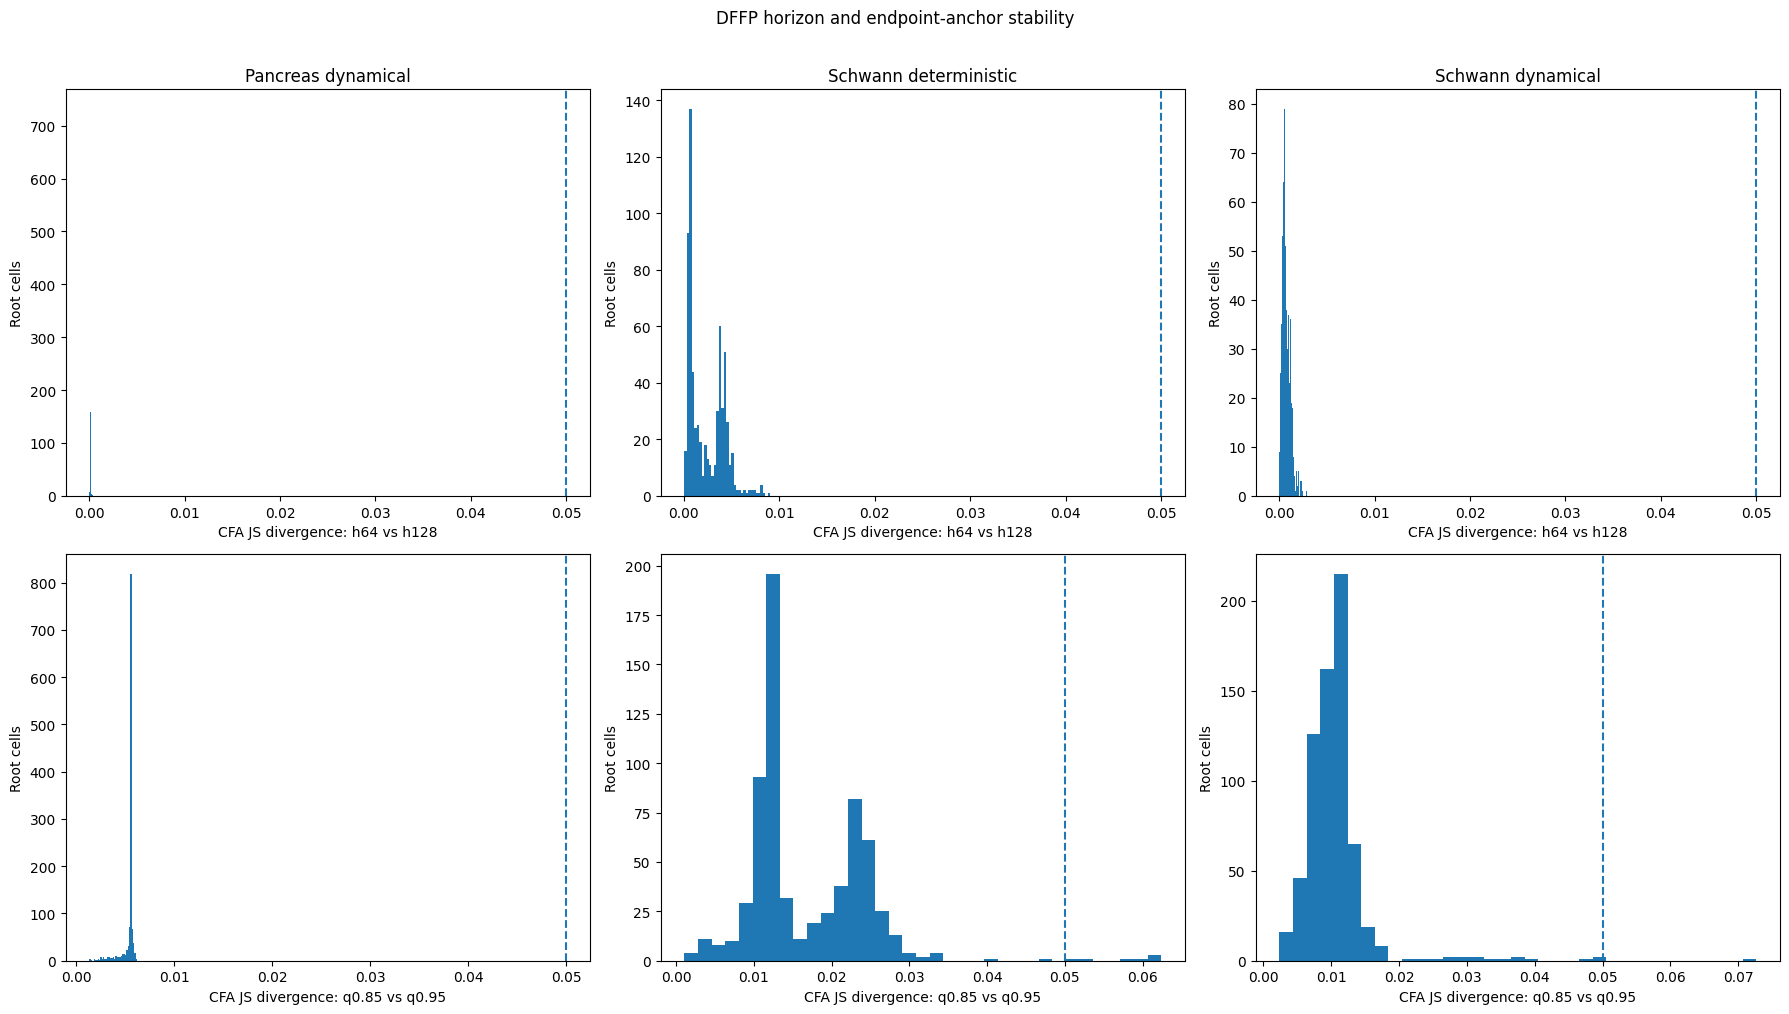

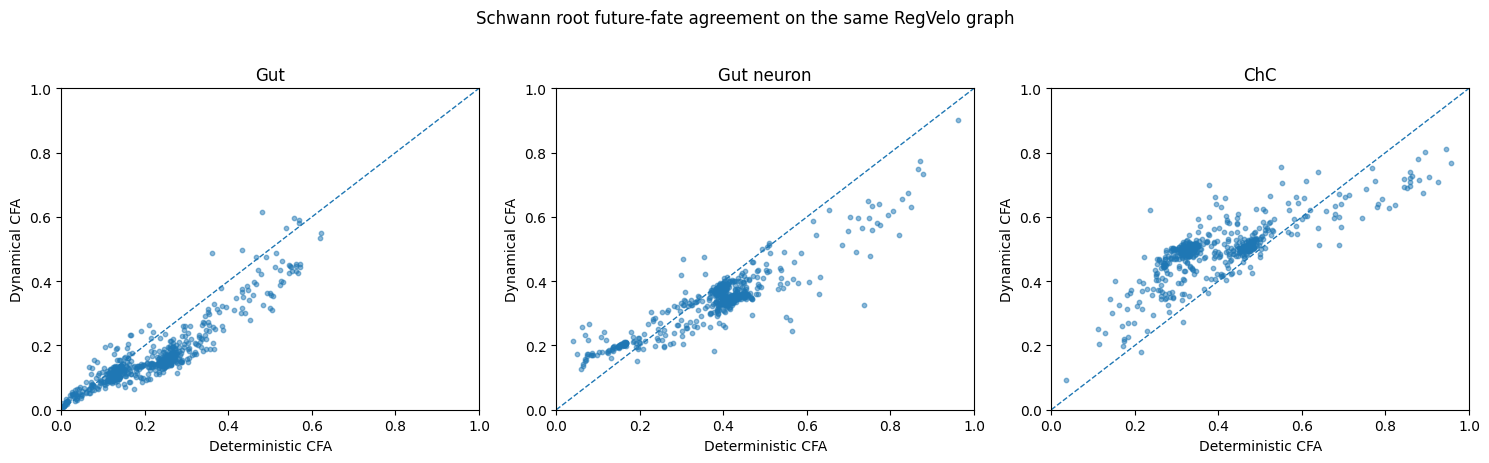

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for column, (source, r64, r128, q85, q95) in enumerate(comparisons):
    _, left_h, right_h = align_result_cells(r64, r128, root_only=True)
    horizon_divergence = row_js(
        r64.future_fate_affinity[left_h],
        r128.future_fate_affinity[right_h],
    )
    axes[0, column].hist(horizon_divergence, bins=35)
    axes[0, column].axvline(0.05, linestyle="--", linewidth=1.5)
    axes[0, column].set_title(source)
    axes[0, column].set_xlabel("CFA JS divergence: h64 vs h128")
    axes[0, column].set_ylabel("Root cells")

    _, left_q, right_q = align_result_cells(q85, q95, root_only=True)
    anchor_divergence = row_js(
        q85.future_fate_affinity[left_q],
        q95.future_fate_affinity[right_q],
    )
    axes[1, column].hist(anchor_divergence, bins=35)
    axes[1, column].axvline(0.05, linestyle="--", linewidth=1.5)
    axes[1, column].set_xlabel("CFA JS divergence: q0.85 vs q0.95")
    axes[1, column].set_ylabel("Root cells")
fig.suptitle("DFFP horizon and endpoint-anchor stability", y=1.01)
fig.tight_layout()
plt.show()

left = schwann_results["deterministic"]["h64"]
right = schwann_results["dynamical"]["h64"]
_, left_index, right_index = align_result_cells(left, right, root_only=True)

fig, axes = plt.subplots(1, len(left.fate_names), figsize=(5 * len(left.fate_names), 4.5))
for fate_index, (axis, fate) in enumerate(zip(np.atleast_1d(axes), left.fate_names)):
    x = left.future_fate_affinity[left_index, fate_index]
    y = right.future_fate_affinity[right_index, fate_index]
    axis.scatter(x, y, s=10, alpha=0.5)
    axis.plot([0, 1], [0, 1], linestyle="--", linewidth=1)
    axis.set_xlim(0, 1)
    axis.set_ylim(0, 1)
    axis.set_title(fate)
    axis.set_xlabel("Deterministic CFA")
    axis.set_ylabel("Dynamical CFA")
fig.suptitle("Schwann root future-fate agreement on the same RegVelo graph", y=1.02)
fig.tight_layout()
plt.show()


## Biological information, not gates

Report Delta, Epsilon, and Gut signed progression descriptively. Negative or mixed values do not fail the method.


In [8]:
sources = {
    "Pancreas": pancreas,
    "Schwann deterministic": schwann_det,
    "Schwann dynamical": schwann_dyn,
}
results_to_summarize = [
    ("Pancreas", pancreas_64, "clusters"),
    ("Schwann deterministic", schwann_results["deterministic"]["h64"], "cell_type_new"),
    ("Schwann dynamical", schwann_results["dynamical"]["h64"], "cell_type_new"),
]
for label, result, annotation_key in results_to_summarize:
    source = sources[label]
    annotations = source.obs.loc[result.cell_ids, annotation_key].astype(str).to_numpy()
    table = pd.DataFrame(
        {
            "annotation": annotations,
            "progression": result.signed_ordering_flux,
        }
    )
    summary = table.groupby("annotation").progression.agg(
        count="count",
        mean="mean",
        forward_fraction=lambda values: float(np.mean(values > 0)),
    )
    print(label)
    display(summary)

Pancreas


,count,mean,forward_fraction
annotation,,,
Alpha,481,0.018979,0.498960
Beta,591,0.085994,0.739425
Delta,70,-0.309134,0.014286
Epsilon,142,0.011887,0.661972
Ngn3 high EP,642,0.059569,0.970405
Pre-endocrine,592,-0.004796,0.439189


Schwann deterministic


,count,mean,forward_fraction
annotation,,,
ChC,762,0.048211,0.692913
Common Progenitor,675,0.051989,0.669630
Gut,245,-0.187450,0.073469
Gut neuron,294,0.023196,0.595238


Schwann dynamical


,count,mean,forward_fraction
annotation,,,
ChC,762,0.039342,0.674541
Common Progenitor,675,0.020214,0.629630
Gut,245,-0.155898,0.106122
Gut neuron,294,0.029544,0.612245
